In [1]:
print("Starting Walmart ETL Pipeline...")

Starting Walmart ETL Pipeline...


**Step1 Data Exploration**

In [2]:
#importing dependencies
import pandas as pd 
import pyodbc
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import numpy as np


In [3]:
df=pd.read_csv('Walmart.csv')

In [4]:
df.shape

(10051, 11)

In [5]:
df.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,$74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,$15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,$46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,$58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,$86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48


In [6]:
df.describe()

,invoice_id,quantity,rating,profit_margin
count,10051.000000,10020.000000,10051.000000,10051.000000
mean,5025.741220,2.353493,5.825659,0.393791
std,2901.174372,1.602658,1.763991,0.090669
min,1.000000,1.000000,3.000000,0.180000
25%,2513.500000,1.000000,4.000000,0.330000
50%,5026.000000,2.000000,6.000000,0.330000
75%,7538.500000,3.000000,7.000000,0.480000
max,10000.000000,10.000000,10.000000,0.570000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10051 entries, 0 to 10050
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_id      10051 non-null  int64  
 1   Branch          10051 non-null  str    
 2   City            10051 non-null  str    
 3   category        10051 non-null  str    
 4   unit_price      10020 non-null  str    
 5   quantity        10020 non-null  float64
 6   date            10051 non-null  str    
 7   time            10051 non-null  str    
 8   payment_method  10051 non-null  str    
 9   rating          10051 non-null  float64
 10  profit_margin   10051 non-null  float64
dtypes: float64(3), int64(1), str(7)
memory usage: 1.4 MB


In [8]:
df.duplicated().sum()

np.int64(51)

In [9]:
df.isnull( ).sum()

invoice_id         0
Branch             0
City               0
category           0
unit_price        31
quantity          31
date               0
time               0
payment_method     0
rating             0
profit_margin      0
dtype: int64

In [10]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()


np.int64(0)

In [11]:
df.shape

(10000, 11)

In [12]:
# Dropping records with null values
df.dropna(inplace=True)

In [13]:
#Verfiey No Nulls?
df.isnull().sum()


invoice_id        0
Branch            0
City              0
category          0
unit_price        0
quantity          0
date              0
time              0
payment_method    0
rating            0
profit_margin     0
dtype: int64

In [14]:
df.shape

(9969, 11)

In [15]:
df['unit_price']=df['unit_price'].str.replace('$','').astype(float)
df.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin
0,1,WALM003,San Antonio,Health and beauty,74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48
1,2,WALM048,Harlingen,Electronic accessories,15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48
2,3,WALM067,Haltom City,Home and lifestyle,46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33
3,4,WALM064,Bedford,Health and beauty,58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33
4,5,WALM013,Irving,Sports and travel,86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48


In [16]:
# 'Add Total column'
df['Total']=df['unit_price'] * df['quantity']
df.head()

,invoice_id,Branch,City,category,unit_price,quantity,date,time,payment_method,rating,profit_margin,Total
0,1,WALM003,San Antonio,Health and beauty,74.69,7.0,05/01/19,13:08:00,Ewallet,9.1,0.48,522.83
1,2,WALM048,Harlingen,Electronic accessories,15.28,5.0,08/03/19,10:29:00,Cash,9.6,0.48,76.40
2,3,WALM067,Haltom City,Home and lifestyle,46.33,7.0,03/03/19,13:23:00,Credit card,7.4,0.33,324.31
3,4,WALM064,Bedford,Health and beauty,58.22,8.0,27/01/19,20:33:00,Ewallet,8.4,0.33,465.76
4,5,WALM013,Irving,Sports and travel,86.31,7.0,08/02/19,10:37:00,Ewallet,5.3,0.48,604.17


In [17]:
print(pyodbc.drivers())

['SQL Server', 'SQL Server Native Client 11.0', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 13 for SQL Server', 'ODBC Driver 18 for SQL Server']


In [18]:
# Connect to Sql server

engine = create_engine(
    "mssql+pyodbc://localhost\\SQLEXPRESS/walmart_db?"
    "driver=ODBC+Driver+18+for+SQL+Server&"
    "trusted_connection=yes&"
    "TrustServerCertificate=yes"
)

df.to_sql("sales", engine, if_exists="replace", index=False)

51

In [19]:
df.shape

(9969, 12)

In [20]:
df.to_csv('walmart_clean_data.csv', index=False)

**KPI**

In [21]:
print("Total Revenue:", df['Total'].sum())
print("Total Transactions:", len(df))
print("Average Rating:", df['rating'].mean())

Total Revenue: 1209726.38
Total Transactions: 9969
Average Rating: 5.828839402146654


**Correlation**

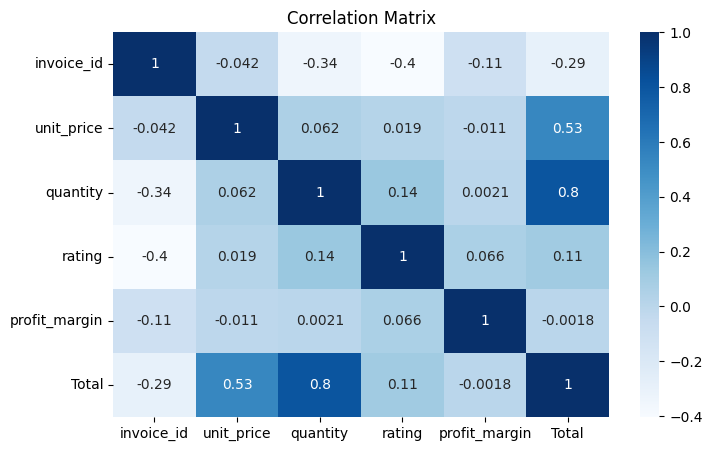

In [22]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,5))

sns.heatmap(corr, annot=True, cmap='Blues')

plt.title("Correlation Matrix")

plt.show()

**Q1. What are the top 5 product categories contributing to total revenue, and what percentage of overall sales does each category represent?**


In [23]:
query = """
with totalcat AS(
select category,sum(total) as Total_Revenue
from sales
group by category
)
select Top(5) * , (Total_Revenue/(select sum(total) from sales))*100 As percentageof_sales
from totalcat
order by Total_Revenue desc;
"""

df_q1 = pd.read_sql(query, engine)
df_q1


,category,Total_Revenue,percentageof_sales
0,Fashion accessories,489480.90,40.462117
1,Home and lifestyle,489250.06,40.443035
2,Electronic accessories,78175.03,6.462208
3,Food and beverages,53471.28,4.420114
4,Sports and travel,52497.93,4.339653


C:\Users\User2\AppData\Local\Temp\ipykernel_7096\3697092238.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


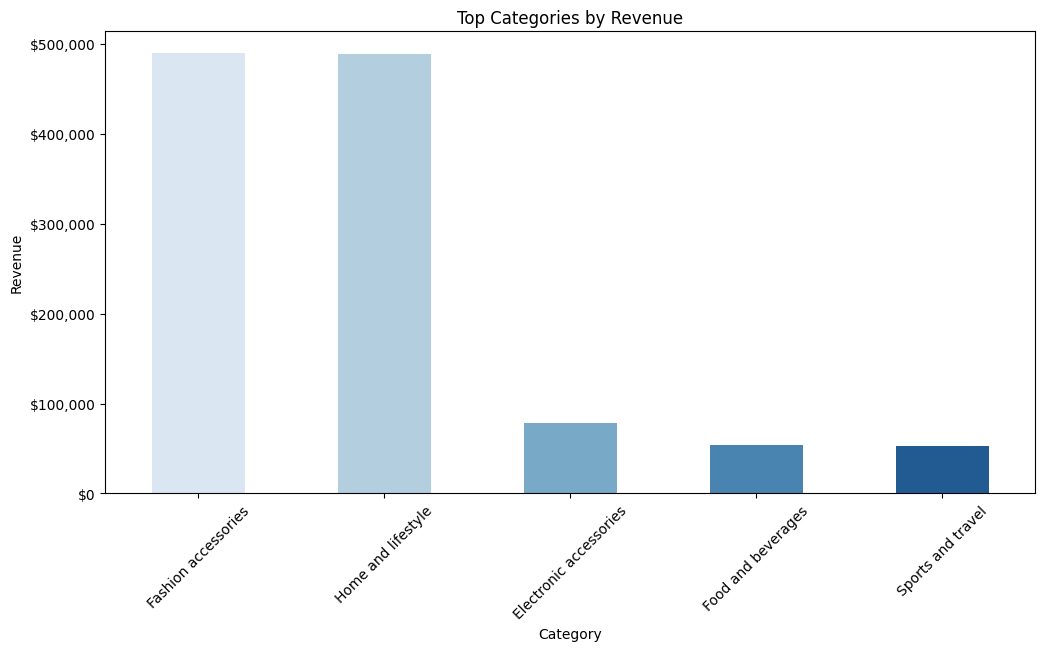

In [24]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df_q1,
    x='category',
    y='Total_Revenue',
    palette='Blues',
    width=0.5)

plt.title("Top Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}')
)
plt.show()

**Q2. Which branch has the highest average basket value (average transaction amount), and how does its transaction volume compare to other branches?**

In [25]:
query = """
WITH countbranch AS (
    SELECT 
        Branch,
        AVG(Total) AS avg_transaction_amount
    FROM sales
    GROUP BY Branch
)

SELECT top (5)*,
       RANK() OVER (ORDER BY avg_transaction_amount DESC) AS branch_rank
FROM countbranch;
"""

df_q2 = pd.read_sql(query, engine)
df_q2


,Branch,avg_transaction_amount,branch_rank
0,WALM017,182.733026,1
1,WALM042,174.057969,2
2,WALM062,163.229600,3
3,WALM066,162.672800,4
4,WALM095,162.622289,5


C:\Users\User2\AppData\Local\Temp\ipykernel_7096\2095864728.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


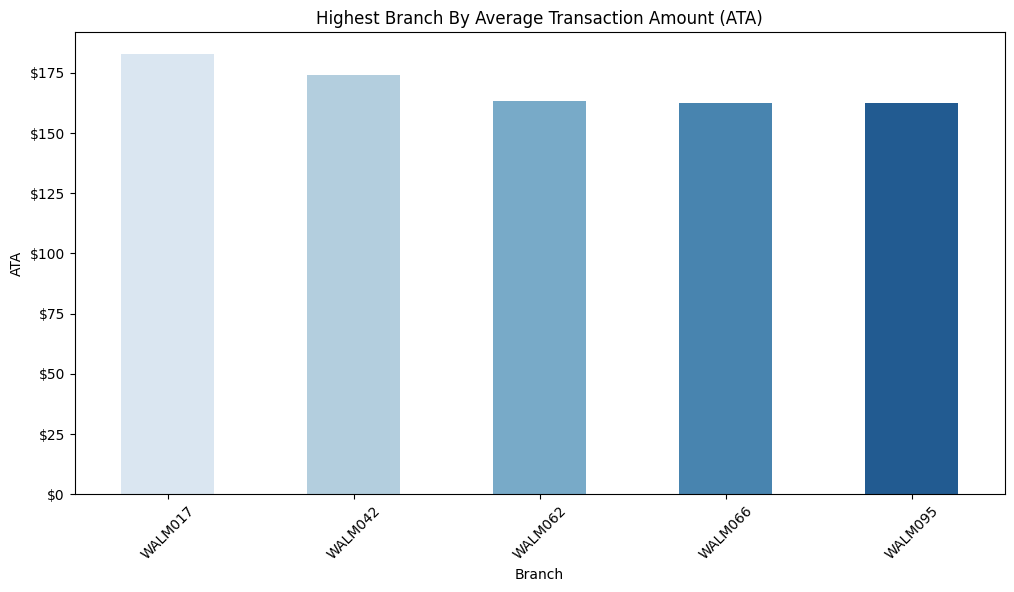

In [26]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df_q2,
    x='Branch',
    y='avg_transaction_amount',
    color='g',
    palette='Blues',
    width=0.5)

plt.title("Highest Branch By Average Transaction Amount (ATA)")
plt.xlabel("Branch")
plt.ylabel("ATA")

plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}')
)
plt.show()

**Q3. What are the true peak sales hours during the day based on both transaction count and total revenue?**

In [27]:
query = """
WITH hourly_stats AS (
    SELECT 
        DATEPART(HOUR, time) AS hour,
        COUNT(*) AS transaction_count,
        SUM(total) AS total_revenue
    FROM sales
    GROUP BY DATEPART(HOUR, time)
)

SELECT Top(5) *,
       RANK() OVER (ORDER BY total_revenue DESC) AS revenue_rank, RANK() OVER (ORDER BY transaction_count DESC) AS transictions_rank

FROM hourly_stats;
"""

df_q3 = pd.read_sql(query, engine)
df_q3

,hour,transaction_count,total_revenue,revenue_rank,transictions_rank
0,15,1191,142016.77,1,1
1,16,1173,134918.07,2,2
2,17,1027,116301.16,4,3
3,19,1024,128581.06,3,4
4,18,986,113072.80,5,5


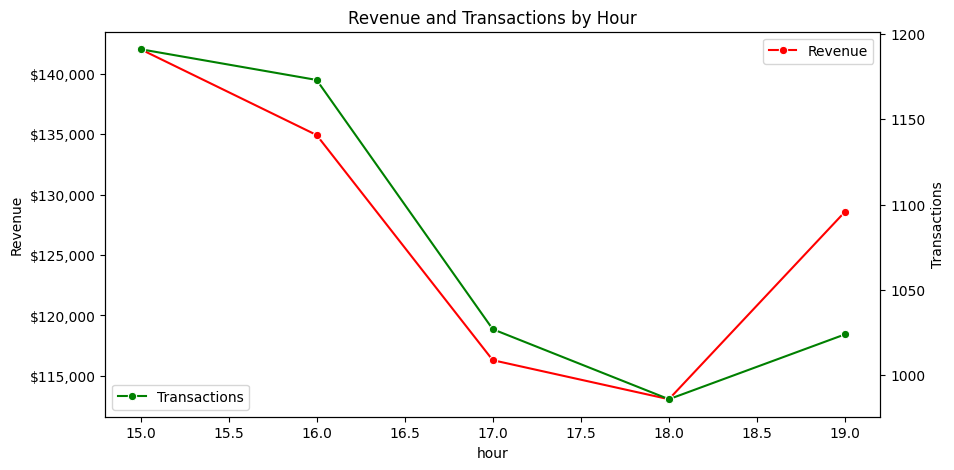

In [28]:
fig, ax1 = plt.subplots(figsize=(10,5))

# First Line
sns.lineplot(
    data=df_q3,
    x='hour',
    y='total_revenue',
    ax=ax1,
    color='red',
    marker='o',
    label='Revenue'
)

ax1.set_ylabel('Revenue')

ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}')
)

# Second Axis
ax2 = ax1.twinx()

sns.lineplot(
    data=df_q3,
    x='hour',
    y='transaction_count',
    ax=ax2,
    color='green',
    marker='o',
    label='Transactions'
)

ax2.set_ylabel('Transactions')

plt.title('Revenue and Transactions by Hour')

ax1.legend(loc='upper right')
ax2.legend(loc='lower left')

plt.show()

**Q4. Display the highest rated category in each Branch**

In [29]:
query = """
select Top(10)*
from
(
select branch, category,avg(rating) as avg_rate,RANK() over (partition by branch order by avg(rating) desc)as rankCinB
from sales
group by Branch,category ) as t
where rankCinB=1
"""

df_sql = pd.read_sql(query, engine)
df_sql

,branch,category,avg_rate,rankCinB
0,WALM001,Electronic accessories,7.450000,1
1,WALM002,Food and beverages,8.250000,1
2,WALM003,Sports and travel,7.500000,1
3,WALM004,Food and beverages,9.300000,1
4,WALM005,Health and beauty,8.366667,1
5,WALM006,Fashion accessories,6.797059,1
6,WALM007,Food and beverages,7.550000,1
7,WALM008,Food and beverages,7.400000,1
8,WALM009,Sports and travel,9.600000,1
9,WALM010,Electronic accessories,9.000000,1


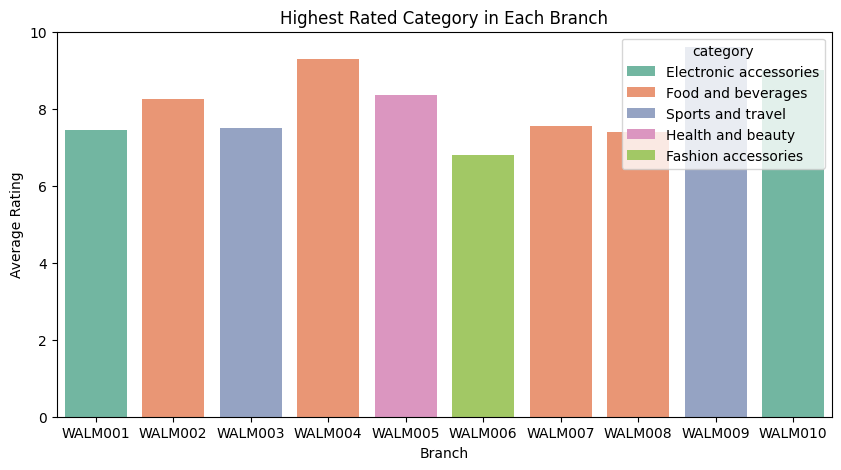

In [30]:

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_sql,
    x='branch',
    y='avg_rate',
    hue='category',
    palette='Set2'
)

plt.title('Highest Rated Category in Each Branch')

plt.ylabel('Average Rating')

plt.xlabel('Branch')

plt.ylim(0,10)

plt.show()

**Q5. What is the busiest day of the week for each branch based on transaction volume?**


In [31]:
query="""WITH sales_day AS (
    SELECT 
        Branch,
        DATENAME(WEEKDAY, CONVERT(DATE, [date], 3)) AS day_name
    FROM sales
)
select Top(20)* 
from(
SELECT 
    Branch,
    day_name,
    COUNT(*) AS no_transactions, RANK() over (partition by branch order by  COUNT(*)  desc) as Rank_day
FROM sales_day
GROUP BY Branch, day_name
) as t
where Rank_day=1;"""
df_sql = pd.read_sql(query, engine)
df_sql

,Branch,day_name,no_transactions,Rank_day
0,WALM001,Thursday,16,1
1,WALM002,Thursday,15,1
2,WALM003,Tuesday,33,1
3,WALM004,Sunday,14,1
4,WALM005,Wednesday,19,1
5,WALM006,Thursday,15,1
6,WALM007,Sunday,12,1
7,WALM007,Friday,12,1
8,WALM008,Tuesday,17,1
9,WALM009,Sunday,42,1


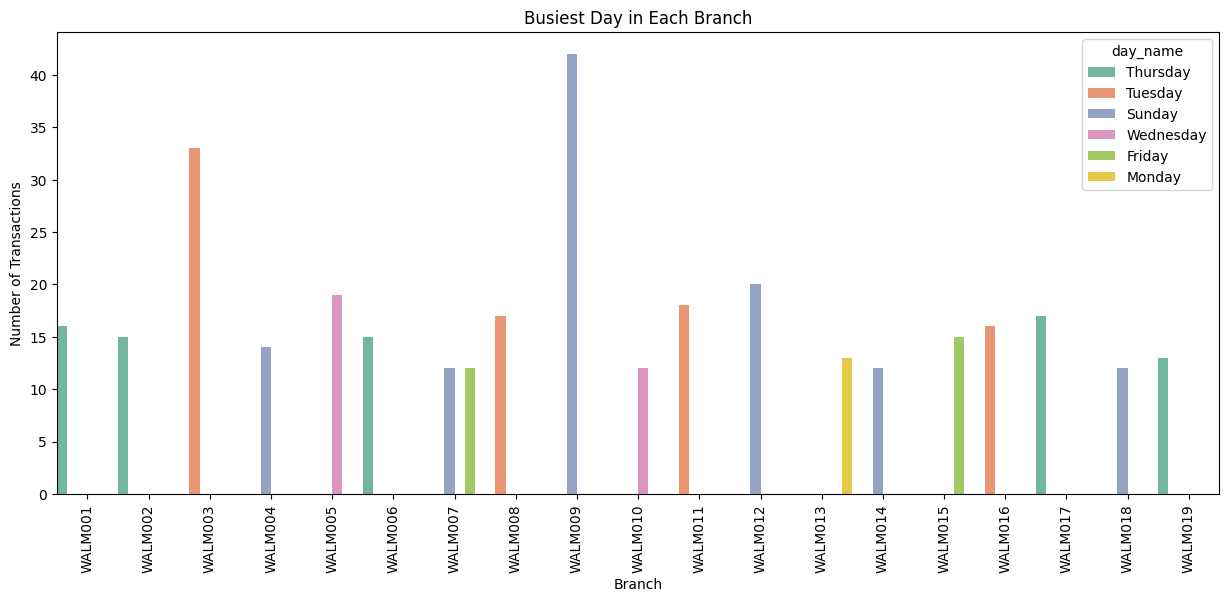

In [32]:
plt.figure(figsize=(15,6))
sns.barplot(
    data=df_sql,
    x='Branch',
    y='no_transactions',
    hue='day_name',
    palette='Set2',
    width=1.0
)

plt.title('Busiest Day in Each Branch')

plt.xlabel('Branch')

plt.ylabel('Number of Transactions')
plt.xticks(rotation=90)
plt.show()

**Q6. What the payments method is perfered?**

In [34]:
query=""" select payment_method, sum(total)
from sales 
group by payment_method  """
df_sql=pd.read_sql(query,engine)
df_sql

,payment_method,
0,Ewallet,457316.07
1,Cash,263589.29
2,Credit card,488821.02
